Kasus 4


===== OPTIMASI UANG JAJAN =====

Gen   0 | Nilai kepuasan: 240
Gen   5 | Nilai kepuasan: 250
Gen  10 | Nilai kepuasan: 250
Gen  15 | Nilai kepuasan: 250
Gen  20 | Nilai kepuasan: 250
Gen  25 | Nilai kepuasan: 250
Gen  30 | Nilai kepuasan: 250
Gen  35 | Nilai kepuasan: 250
Gen  40 | Nilai kepuasan: 250
Gen  45 | Nilai kepuasan: 250
Gen  50 | Nilai kepuasan: 250
Gen  55 | Nilai kepuasan: 250
Gen  60 | Nilai kepuasan: 250
Gen  65 | Nilai kepuasan: 250
Gen  70 | Nilai kepuasan: 250
Gen  75 | Nilai kepuasan: 250
Gen  80 | Nilai kepuasan: 250
Gen  85 | Nilai kepuasan: 250
Gen  90 | Nilai kepuasan: 250
Gen  95 | Nilai kepuasan: 250

===== HASIL AKHIR =====
Pilihan: ['Makan', 'Kopi', 'Transport', 'Internet']
Total biaya: 50000
Total kepuasan: 250
Penjelasan: Pengeluaran optimal sesuai budget.


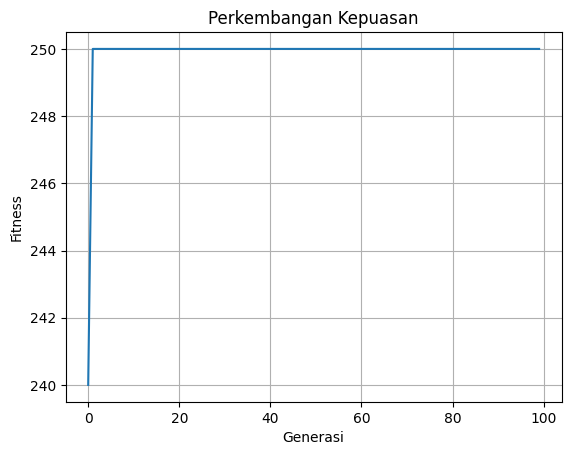

In [ ]:
import random
import matplotlib.pyplot as plt

# =========================================================
# DATA PENGELUARAN
# =========================================================
items = [
    ("Makan", 20000, 80),
    ("Kopi", 15000, 60),
    ("Jajan", 10000, 50),
    ("Transport", 10000, 70),
    ("Internet", 5000, 40),
]

BUDGET = 50000

POP_SIZE = 30
GENERATIONS = 100
MUTATION_RATE = 0.2

# =========================================================
# INIT
# =========================================================
def create_individual():
    return [random.randint(0,1) for _ in items]

def init_population():
    return [create_individual() for _ in range(POP_SIZE)]

# =========================================================
# FITNESS
# =========================================================
def fitness(ind):
    total_cost = 0
    total_value = 0

    for gene, (name, cost, value) in zip(ind, items):
        if gene == 1:
            total_cost += cost
            total_value += value

    if total_cost > BUDGET:
        return 0

    return total_value

# =========================================================
# SELECTION
# =========================================================
def selection(pop):
    return max(random.sample(pop, 3), key=fitness)

# =========================================================
# CROSSOVER
# =========================================================
def crossover(p1, p2):
    point = random.randint(1, len(p1)-1)
    return p1[:point] + p2[point:]

# =========================================================
# MUTATION
# =========================================================
def mutate(ind):
    for i in range(len(ind)):
        if random.random() < MUTATION_RATE:
            ind[i] = 1 - ind[i]
    return ind

# =========================================================
# DECODE
# =========================================================
def decode(ind):
    chosen = []
    total_cost = 0
    total_value = 0

    for gene, (name, cost, value) in zip(ind, items):
        if gene == 1:
            chosen.append(name)
            total_cost += cost
            total_value += value

    return chosen, total_cost, total_value

# =========================================================
# GA
# =========================================================
def GA():
    pop = init_population()
    best_hist = []

    print("\n===== OPTIMASI UANG JAJAN =====\n")

    for gen in range(GENERATIONS):

        pop = sorted(pop, key=fitness, reverse=True)

        best = pop[0]
        best_fit = fitness(best)

        best_hist.append(best_fit)

        if gen % 5 == 0:
            print(f"Gen {gen:3d} | Nilai kepuasan: {best_fit}")

        new_pop = pop[:2]

        while len(new_pop) < POP_SIZE:
            p1 = selection(pop)
            p2 = selection(pop)

            child = crossover(p1, p2)
            child = mutate(child)

            new_pop.append(child)

        pop = new_pop

    # =====================================================
    # HASIL
    # =====================================================
    best = sorted(pop, key=fitness, reverse=True)[0]
    chosen, cost, value = decode(best)

    print("\n===== HASIL AKHIR =====")
    print("Pilihan:", chosen)
    print("Total biaya:", cost)
    print("Total kepuasan:", value)

    if cost <= BUDGET:
        print("Penjelasan: Pengeluaran optimal sesuai budget.")
    else:
        print("Penjelasan: Melebihi budget (tidak valid).")

    # =====================================================
    # VISUAL
    # =====================================================
    plt.figure()
    plt.plot(best_hist)
    plt.title("Perkembangan Kepuasan")
    plt.xlabel("Generasi")
    plt.ylabel("Fitness")
    plt.grid()
    plt.show()

# RUN
GA()